In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.datasets import make_blobs



In [2]:
n_groups=3
n_samples=160

# X, y = make_moons(n_samples=100, random_state=42)
X, y = make_blobs(n_samples=n_samples, centers=n_groups)


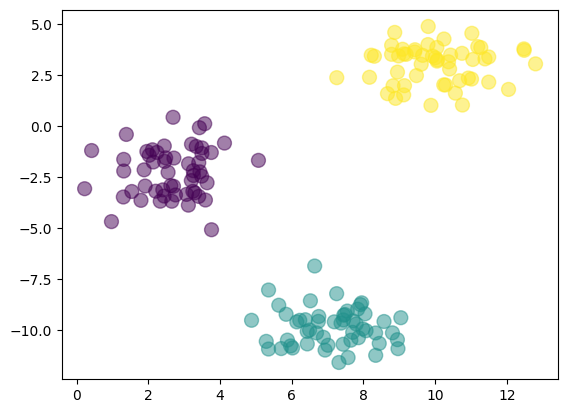

In [3]:
plt.scatter(X[:,0], X[:,1], s=100, c=y, alpha=0.5)
plt.show()

In [4]:
#подготовка тестового и тренировочного наборов данных
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state=1)

In [5]:
#подключение классификатора KNN
from sklearn.neighbors import KNeighborsClassifier
n_neighbors=5

model = KNeighborsClassifier(n_neighbors = n_neighbors)
model.fit(X_train,y_train)

score = model.score(X_test,y_test)
print("The accuracy is ",score*100)

The accuracy is  100.0


In [6]:
y_pred = model.predict(X_test)
y_pred == y_test

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [7]:
!pip install mlxtend --upgrade --no-deps -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 6.0 MB/s eta 0:00:00


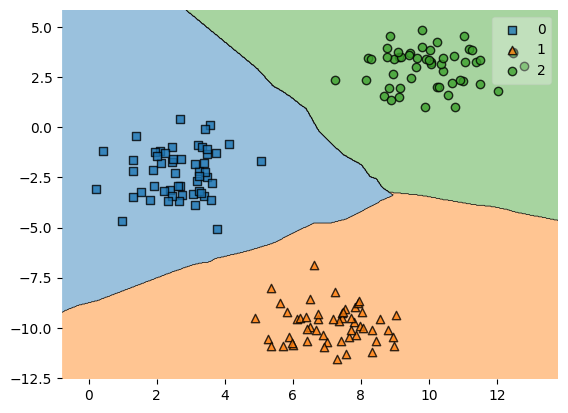

In [8]:

from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X, y, clf=model)
plt.show()

# KNN method, try k = 3

In [9]:
from sklearn.neighbors import KNeighborsClassifier
n_neighbors=3

model = KNeighborsClassifier(n_neighbors = n_neighbors)
model.fit(X_train,y_train)

score = model.score(X_test,y_test)
print("The accuracy is ",score*100)

The accuracy is  100.0


# Find optimal K using cross validation

In [10]:
from sklearn.model_selection import cross_val_score
# Создание списка значений k, которые вы хотите оценить
k_values = [3, 5, 7, 9, 10, 11, 20]

# Инициализация списка для сохранения средних оценок точности для каждого значения k
mean_scores = []

# Перебор значений k
for k in k_values:
    # Создание модели k-ближайших соседей
    knn = KNeighborsClassifier(n_neighbors=k)

    # Вычисление средней оценки точности с использованием перекрестной проверки
    scores = cross_val_score(knn, X, y, cv=5, scoring='accuracy')  # cv=5 означает 5-кратную перекрестную проверку
    mean_scores.append(np.mean(scores))

# Вывод результатов
for k, score in zip(k_values, mean_scores):
    print("k =", k, "Mean Accuracy:", score)






k = 3 Mean Accuracy: 1.0
k = 5 Mean Accuracy: 1.0
k = 7 Mean Accuracy: 1.0
k = 9 Mean Accuracy: 1.0
k = 10 Mean Accuracy: 1.0
k = 11 Mean Accuracy: 1.0
k = 20 Mean Accuracy: 1.0
